# Experimento multi-base — OES/DES/SES em 8 bases

Aplica **o mesmo pipeline** do experimento do artigo (pool da Tabela 3 →
SES-GA com fitness de acurácia+diversidade → DES → OES → 5 métricas → Wilcoxon)
a **8 bases**, em dois modos de pré-processamento (`baseline` e `melhorado`).
É o mesmo tratamento feito para Finnish e Maxwell, generalizado, com o
pré-processamento identificado automaticamente por base.

> O notebook do **artigo original** (apenas Finnish + Maxwell, replicação fiel)
> é o `01_replicacao_OES.ipynb` — este aqui é separado.

Seis bases são de **estimação de esforço de software**; **debutanizer** e
**abalone** foram incluídas a pedido para avaliar os 3 métodos, mas **não são**
de esforço — são regressão genérica, e servem de contraste (nelas os 3 métodos
atingem sMAPE baixo porque o problema é mais fácil).

Métricas sempre no **esforço bruto** (alvo log-transformado só no treino quando
assimétrico). Para SES/DES/OES: menor sMAPE/MRE/MASE é melhor; maior NSE/COD.

In [11]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
_here = Path.cwd(); ROOT = _here if (_here / "src").exists() else _here.parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
from IPython.display import Image, display
import data_multi as dm
import run_experiment_multi as rm
import figures as fg
print("Setup OK. Bases:", dm.DATASETS)

Setup OK. Bases: ['finnish', 'maxwell', 'desharnais', 'china', 'kitchenham', 'coc81', 'debutanizer', 'abalone']


## Fontes e categoria de cada base (sem duplicatas)

Nenhuma base é duplicata das outras. As fontes:

In [12]:
pd.set_option("display.max_colwidth", None)
pd.DataFrame([{"Base": n, "Categoria": dm.CATEGORIA[n], "Fonte": dm.FONTE[n]}
              for n in dm.DATASETS])

,Base,Categoria,Fonte
0,finnish,SEE,"TIEKE (Finlandia), 1997; repositorio PROMISE/figshare. Base do artigo."
1,maxwell,SEE,"K.D. Maxwell, banco comercial finlandes; Applied Statistics for Software Managers (Prentice-Hall, 2002); Zenodo. Base do artigo."
2,desharnais,SEE,"J.M. Desharnais (1989), tese de mestrado, UQAM; 81 projetos canadenses; repositorio PROMISE."
3,china,SEE,China dataset (499 projetos por pontos de funcao); repositorio PROMISE / derivado do ISBSG.
4,kitchenham,SEE,"Kitchenham, Pfleeger, McColl & Eagan (2002), 'An empirical study of maintenance and development estimation accuracy'; PROMISE."
5,coc81,SEE,"B. Boehm, Software Engineering Economics (Prentice-Hall, 1981); 63 projetos COCOMO; repositorio PROMISE (coc81)."
6,debutanizer,regressao generica (nao-SEE),"Coluna debutanizadora (sensor virtual de processo quimico). Fortuna et al., Soft Sensors for Monitoring and Control of Industrial Processes (Springer, 2007); benchmark do OpenML. NAO e estimacao de esforco."
7,abalone,regressao generica (nao-SEE),Abalone (prever idade/aneis a partir de medidas fisicas). Nash et al. (1994); UCI Machine Learning Repository. NAO e estimacao de esforco.


## Fase 1 — Pré-processamento identificado por base

Linhas válidas, nº de features `baseline`→`melhorado`, se o alvo foi
log-transformado, e o que as regras automáticas removeram (constantes,
variância≈0, correlação>0.98, informação mútua≈0). IDs, datas, strings e
**vazamento** (ex.: China `PDR_*`/`N_effort`, `Duration`/`Length`/`Time`,
COCOMO `months`) saem nos dois modos.

In [13]:
recs = []
for n in dm.DATASETS:
    db = dm.build(n, "baseline"); dv = dm.build(n, "melhorado"); p = dv["prep"]
    drops = "; ".join(filter(None, [
        ("const: " + ",".join(p["drop_const"])) if p["drop_const"] else "",
        ("var≈0: " + ",".join(p["drop_nzv"])) if p["drop_nzv"] else "",
        ("corr>0.98: " + ",".join(p["drop_corr"])) if p["drop_corr"] else "",
        ("MI≈0: " + ",".join(p["drop_mi"])) if p["drop_mi"] else ""])) or "—"
    recs.append({"Base": n, "Linhas": p["n_linhas"], "Feats base": db["n_features"],
                 "Feats melh": dv["n_features"], "log alvo": p["log_alvo"],
                 "Removidos no melhorado": drops})
pd.DataFrame(recs)

,Base,Linhas,Feats base,Feats melh,log alvo,Removidos no melhorado
0,finnish,405,37,37,True,—
1,maxwell,62,24,15,True,"MI≈0: Har,Syear,T01,T03,T04,T05,T06,T13,Telonuse"
2,desharnais,77,8,6,True,corr>0.98: PointsAjust; MI≈0: TeamExp
3,china,499,10,10,True,const: Dev.Type
4,kitchenham,135,5,4,True,MI≈0: First.estimate.method
5,coc81,63,15,10,True,"const: docu,flex,pcon,prec,resl,ruse,site,team; MI≈0: cplx,ltex,plex,pvol,sced"
6,debutanizer,2394,7,6,True,corr>0.98: u7
7,abalone,4177,8,7,True,corr>0.98: diameter


## Fases 2–3 — pipeline completo (holdout, seed 42)

Roda pool → SES-GA → DES → OES nos dois modos, nas 8 bases. Resumo do **OES**
(baseline vs melhorado). *(Leva ~1 min; abalone tem 4177 linhas.)*

In [14]:
res = {n: {md: rm.rodar(n, md) for md in ["baseline", "melhorado"]} for n in dm.DATASETS}
recs = []
for n in dm.DATASETS:
    for md in ["baseline", "melhorado"]:
        o = res[n][md]["rows"]["Proposed"]
        recs.append({"Base": n, "Modo": md, **{m: round(o[m], 3) for m in rm.MC}})
pd.DataFrame(recs)

,Base,Modo,sMAPE,MRE,MASE,NSE,COD
0,finnish,baseline,54.862,0.728,0.369,0.571,0.695
1,finnish,melhorado,57.745,0.758,0.495,0.263,0.415
2,maxwell,baseline,51.705,0.902,0.403,0.462,0.871
3,maxwell,melhorado,33.019,0.380,0.330,0.848,0.862
4,desharnais,baseline,37.904,0.491,0.539,0.121,0.239
5,desharnais,melhorado,34.925,0.406,0.444,0.607,0.623
6,china,baseline,77.587,2.398,0.554,0.436,0.459
7,china,melhorado,69.815,1.302,0.836,-8.118,0.179
8,kitchenham,baseline,26.352,0.384,0.183,0.921,0.928
9,kitchenham,melhorado,31.242,0.406,1.810,-22.493,0.993


Comparação dos **15 modelos** (baseline → melhorado, com Δ) fica em
`outputs/multi/tables/<base>_compare.csv`. Abaixo, só os três ensembles de uma
base (troque `BASE`):

In [15]:
BASE = "coc81"
p = ROOT / "outputs" / "multi" / "tables" / f"{BASE}_compare.csv"
if not p.exists():
    rm.holdout()
df = pd.read_csv(p)
df[df["Model"].isin(["Static", "DES", "Proposed"])]

,Model,sMAPE_base,sMAPE_melh,sMAPE_delta,MRE_base,MRE_melh,MRE_delta,MASE_base,MASE_melh,MASE_delta,NSE_base,NSE_melh,NSE_delta,COD_base,COD_melh,COD_delta
12,Static,91.3836,104.8837,13.5001,3.2828,1.6128,-1.6700,0.4439,0.5689,0.1250,0.1216,0.3477,0.2261,0.2690,0.5054,0.2364
13,DES,94.2862,105.2939,11.0077,3.8148,1.0631,-2.7517,0.4541,0.4858,0.0317,0.1425,0.5123,0.3698,0.2341,0.8368,0.6027
14,Proposed,92.4454,104.6411,12.1957,3.5420,1.3264,-2.2155,0.4467,0.5258,0.0791,0.1330,0.4370,0.3040,0.2511,0.6928,0.4417


## O OES (Proposto) é o melhor?

Posição do OES entre os 15 modelos, por base e modo.

In [16]:
rk = []
for n in dm.DATASETS:
    for md in ["baseline", "melhorado"]:
        r = rm.rank_oes(res[n][md]["rows"])
        rk.append({"Base": n, "Modo": md,
                   "OES é #1 em": f"{sum(1 for m in rm.MC if r[m][0]=='Proposed')}/5",
                   "rank mediano OES": int(np.median([r[m][2] for m in rm.MC])),
                   "vence sMAPE": r["sMAPE"][0]})
pd.DataFrame(rk)

,Base,Modo,OES é #1 em,rank mediano OES,vence sMAPE
0,finnish,baseline,1/5,2,ET
1,finnish,melhorado,0/5,10,ET
2,maxwell,baseline,0/5,5,BG
3,maxwell,melhorado,1/5,3,Static
4,desharnais,baseline,2/5,2,Proposed
5,desharnais,melhorado,0/5,3,DES
6,china,baseline,0/5,4,DES
7,china,melhorado,0/5,12,ET
8,kitchenham,baseline,2/5,2,ET
9,kitchenham,melhorado,1/5,10,ET


## Teste de hipótese: de H0 para H1 (quem é quem)

O Wilcoxon do artigo (Tabela 6) compara **predito × real** de cada modelo — não
diz qual método vence. Para decidir **quem é melhor** fazemos um teste **pareado
método × método** sobre os erros absolutos por instância, em dois passos:

1. **H0**: os dois métodos têm o mesmo desempenho (mediana das diferenças de
   erro = 0). **H1 (bilateral)**: diferem. Calcula-se o p-valor de Wilcoxon
   pareado.
2. **Se p ≥ 0,05** → não rejeita H0 → *empate* (não dá para eleger vencedor).
   **Se p < 0,05** → rejeita H0; aí a **direção** (método com menor erro absoluto
   mediano) define a H1 específica *‘A erra menos que B’* — é isso que responde
   **quem é quem**.

Fazemos as 3 comparações par a par (SES×DES, SES×OES, DES×OES).
⚠️ **Significância ≠ relevância**: em bases grandes (debutanizer, abalone)
diferenças minúsculas já rejeitam H0; em bases pequenas (COCOMO81 ~19 pontos de
teste) nem diferenças reais atingem significância — por isso o ranking por erro
acompanha o p-valor.

In [17]:
sig = []
for n in dm.DATASETS:
    ens_te = res[n]["melhorado"]["ens_te"]; y = res[n]["melhorado"]["d"]["y_test_raw"]
    ordem = " > ".join(rm.ranking_metodos(ens_te, y))   # menor erro -> maior
    for r in rm.comparar_pares(ens_te, y):
        sig.append({"Base": n, "Cat": dm.CATEGORIA[n], "Ranking (menor erro→)": ordem, **r})
pd.DataFrame(sig)

,Base,Cat,Ranking (menor erro→),Par,medErr_A,medErr_B,p,Rejeita_H0,Vencedor_H1
0,finnish,SEE,SES > OES > DES,SES vs DES,936.800,1143.900,0.0434,sim,SES
1,finnish,SEE,SES > OES > DES,SES vs OES,936.800,1071.500,0.2148,nao,empate
2,finnish,SEE,SES > OES > DES,DES vs OES,1143.900,1071.500,0.0129,sim,OES
3,maxwell,SEE,DES > OES > SES,SES vs DES,1734.200,1534.200,0.1564,nao,empate
4,maxwell,SEE,DES > OES > SES,SES vs OES,1734.200,1574.800,0.4413,nao,empate
5,maxwell,SEE,DES > OES > SES,DES vs OES,1534.200,1574.800,0.0799,nao,empate
6,desharnais,SEE,DES > OES > SES,SES vs DES,1002.800,628.200,0.1875,nao,empate
7,desharnais,SEE,DES > OES > SES,SES vs OES,1002.800,855.000,0.1600,nao,empate
8,desharnais,SEE,DES > OES > SES,DES vs OES,628.200,855.000,0.2768,nao,empate
9,china,SEE,SES > OES > DES,SES vs DES,854.800,931.500,0.4788,nao,empate


## Scatter SES/DES/OES por base (modo melhorado)

O OES fica entre SES e DES **por construção** (é a média dos dois). Note os
pontos longe da diagonal — o erro relativo alto nas bases de SEE é generalizado,
não só outliers.

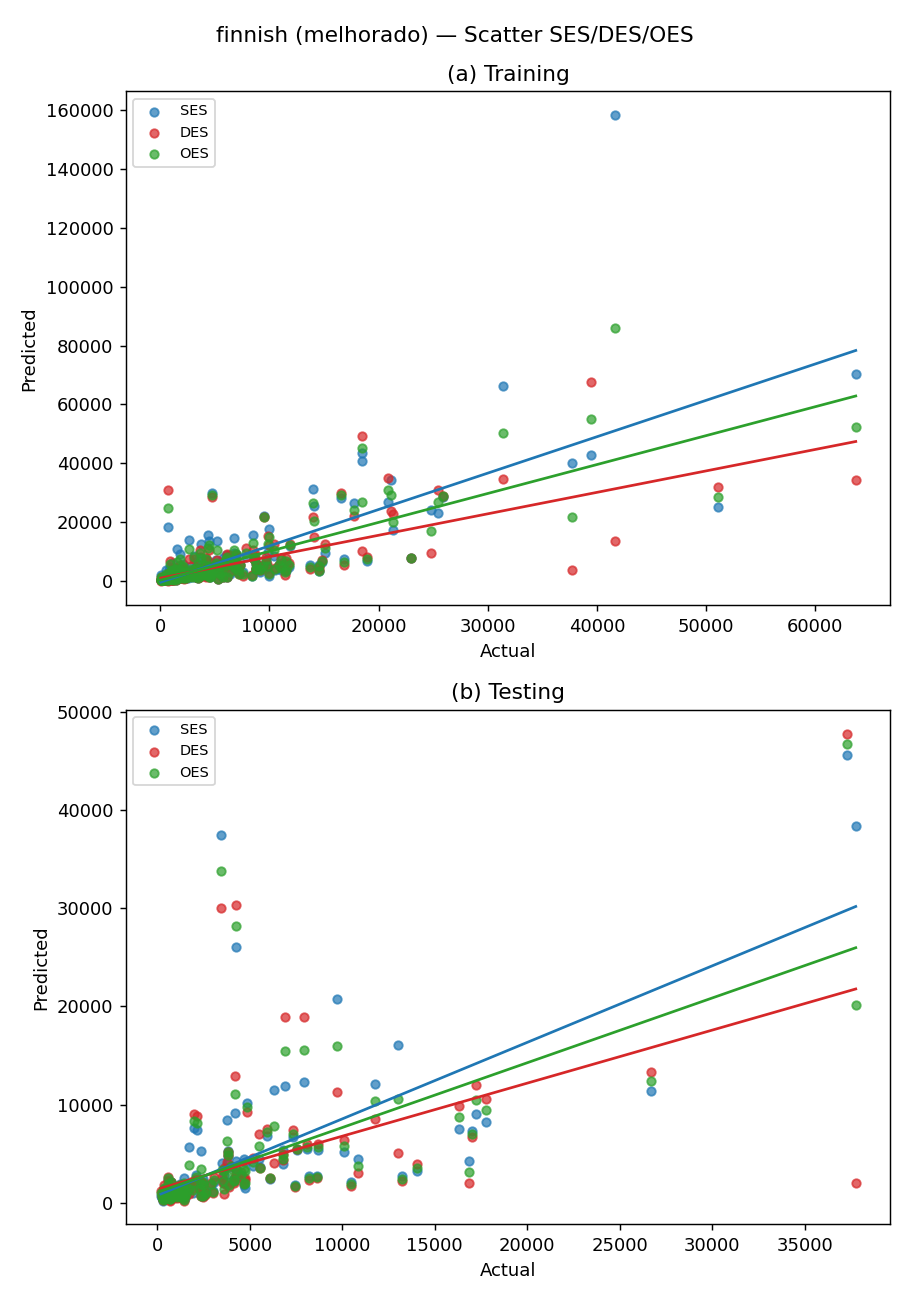

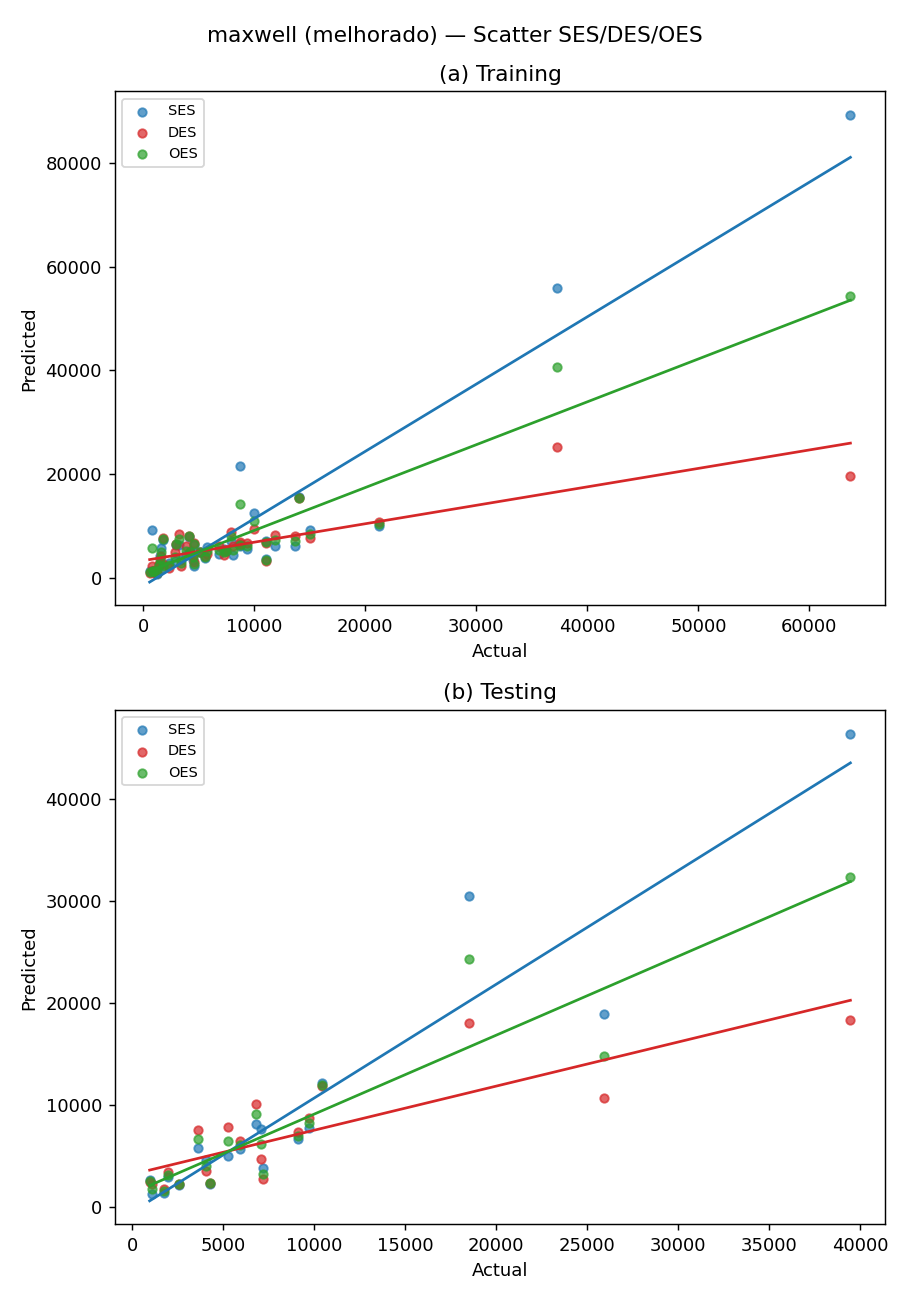

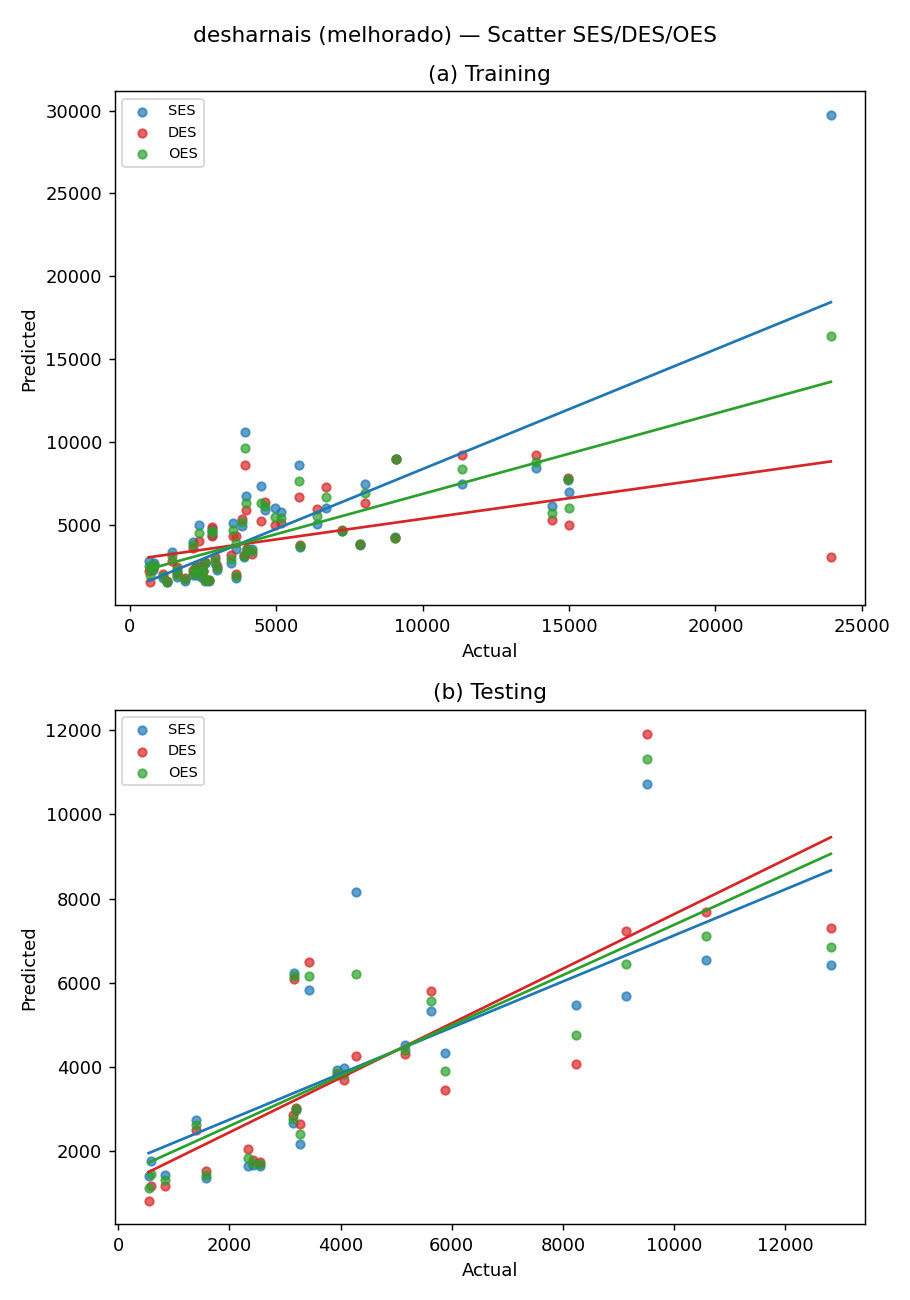

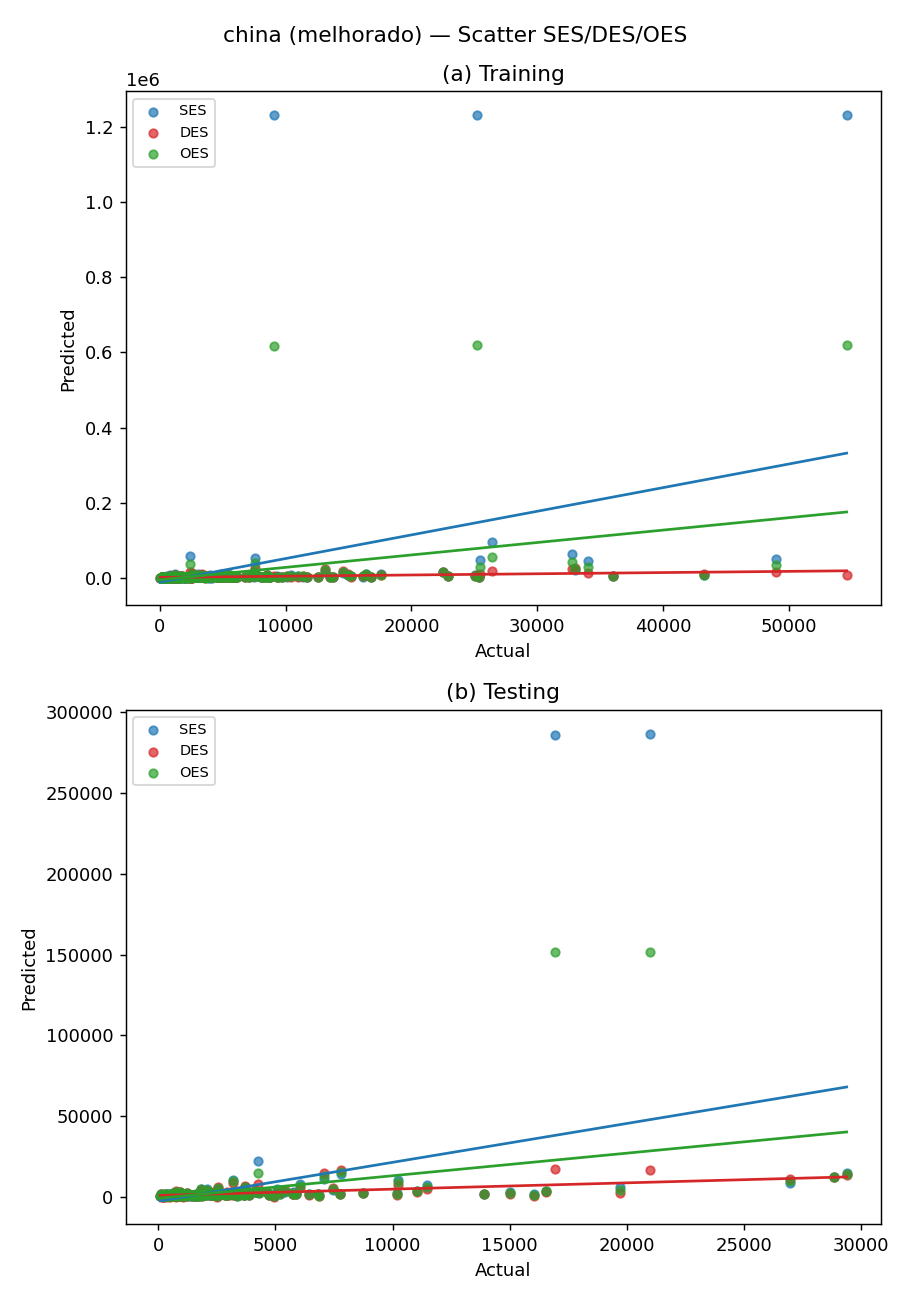

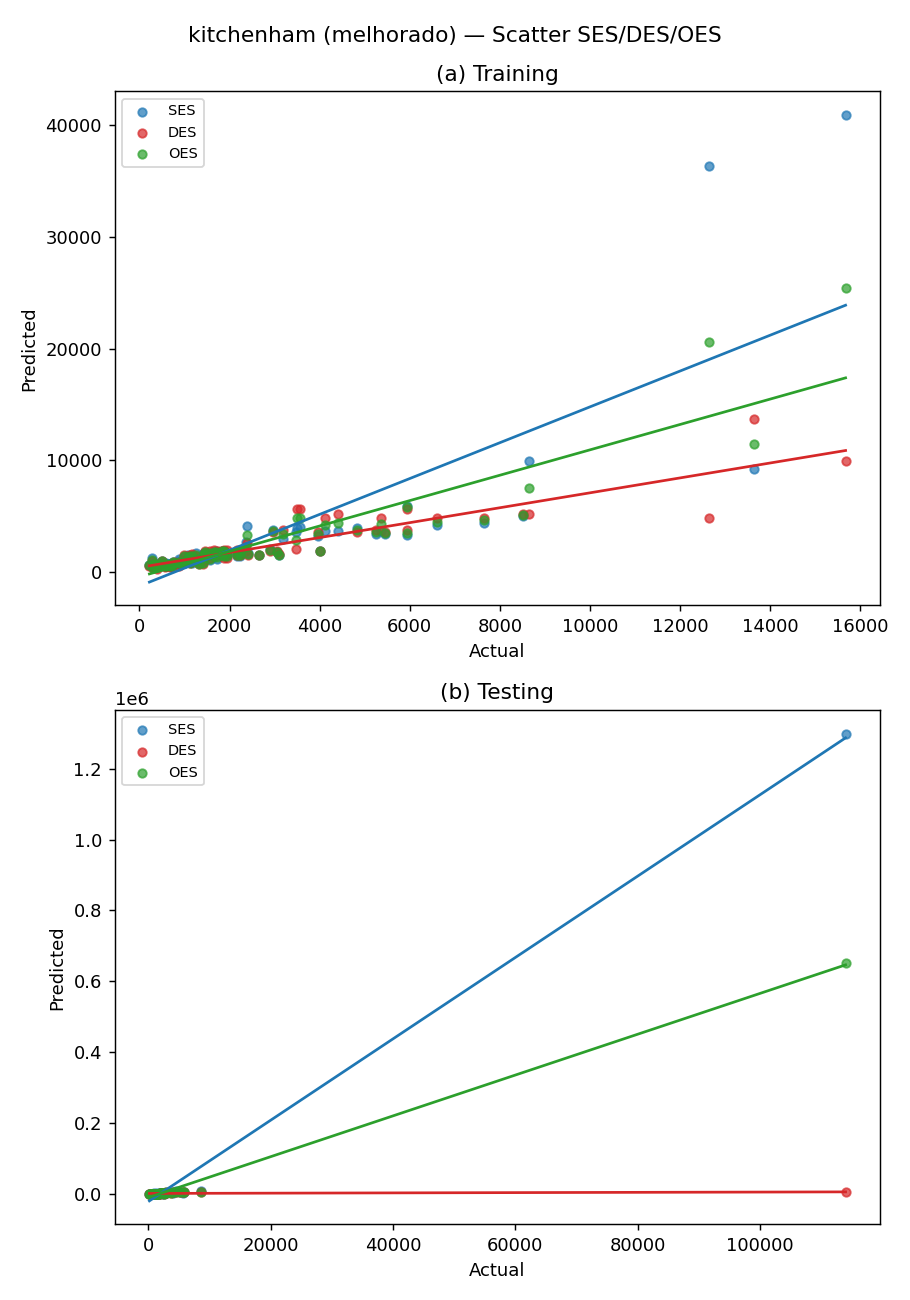

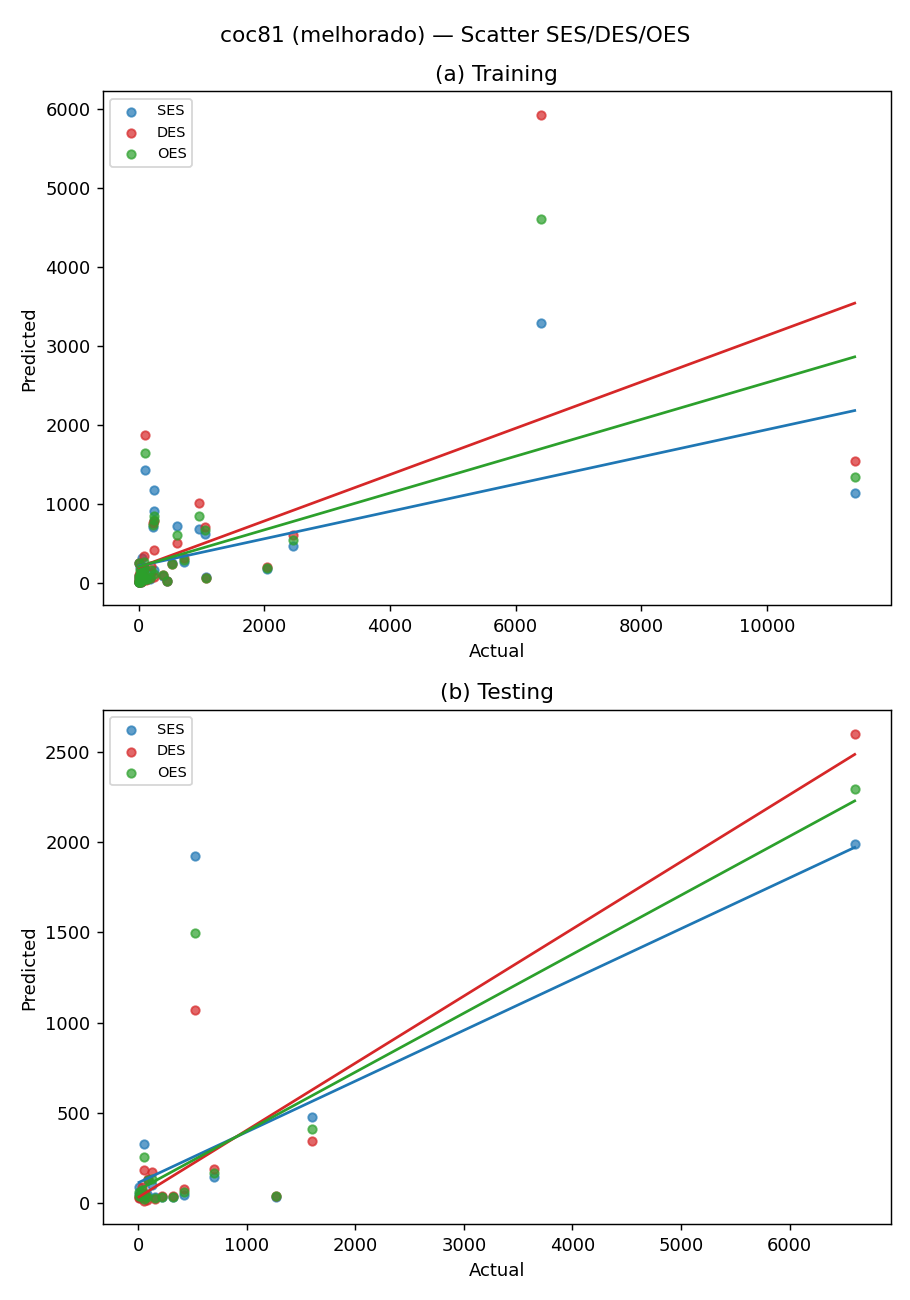

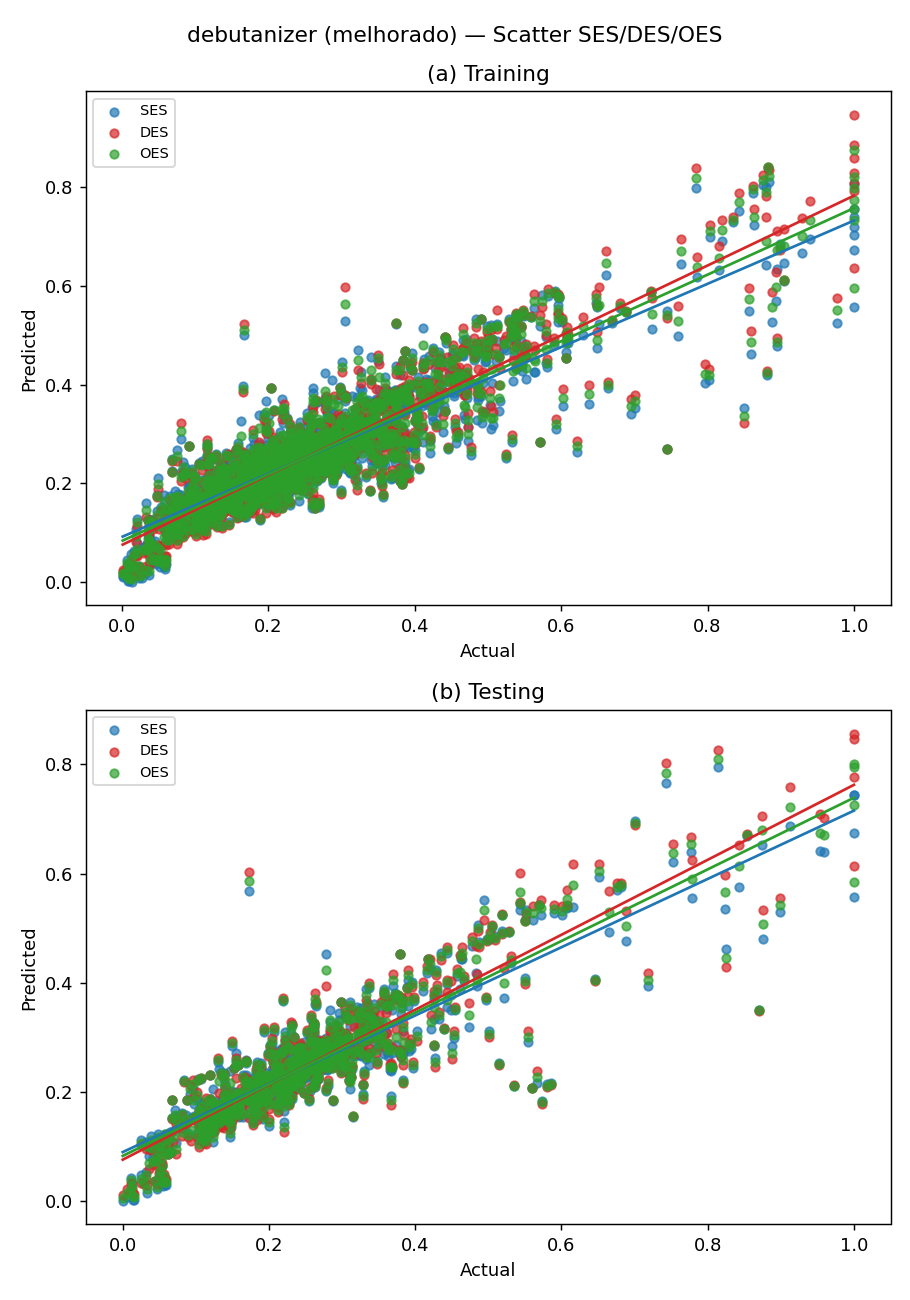

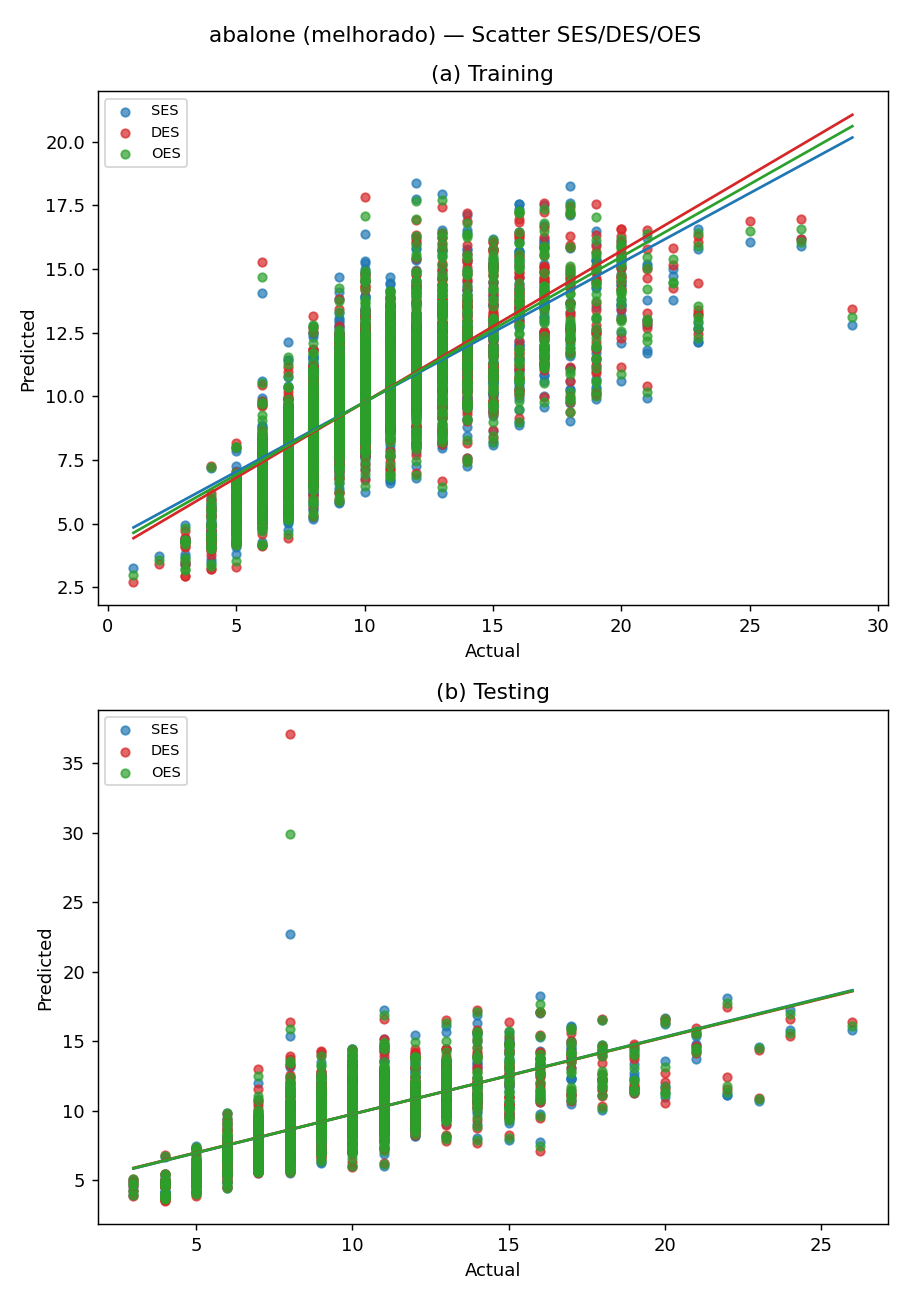

In [18]:
FIG = ROOT / "outputs" / "multi" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
for n in dm.DATASETS:
    d = res[n]["melhorado"]["d"]; path = FIG / f"{n}_scatter.png"
    fg.scatter_fig(str(path), f"{n} (melhorado) — Scatter SES/DES/OES",
                   res[n]["melhorado"]["ens_tr"], res[n]["melhorado"]["ens_te"],
                   d["y_train_raw"], d["y_test_raw"])
    display(Image(str(path)))

## Robustez — CV repetida (mediana ± desvio), OES baseline vs melhorado

Mediana e desvio sobre 5 splits estratificados (a mediana é robusta a partições
catastróficas). Bases grandes foram subamostradas (cap=700) só na robustez.
Carregamos o resultado já calculado; para **regenerar** rode
`rm.robustez()` (e `rm.robustez(subset=["debutanizer","abalone"])` para as
grandes), depois `rm._append_robustez_report()`.

In [19]:
rob = ROOT / "outputs" / "multi" / "tables" / "robustez_oes.csv"
if not rob.exists():
    rm.robustez()
pd.read_csv(rob)

,Dataset,Modo,sMAPE_med,sMAPE_std,MRE_med,MRE_std,MASE_med,MASE_std,NSE_med,NSE_std,COD_med,COD_std
0,finnish,baseline,62.494,3.274,1.045,1.420000e-01,0.429,0.037,0.556,0.044,0.588,0.039
1,finnish,melhorado,56.871,3.449,0.809,1.180000e-01,0.467,0.084,0.500,0.837,0.528,0.150
2,maxwell,baseline,60.026,6.401,1.017,2.790000e-01,0.417,0.258,0.514,0.715,0.587,0.183
3,maxwell,melhorado,48.532,7.458,0.752,9.670000e-01,0.448,0.057,0.662,0.205,0.728,0.232
4,desharnais,baseline,40.287,8.172,0.551,2.090000e-01,0.500,0.066,0.453,0.128,0.474,0.087
5,desharnais,melhorado,34.530,3.966,0.429,1.000000e-01,0.466,0.033,0.446,0.136,0.461,0.156
6,china,baseline,69.869,3.409,1.385,5.160000e-01,0.525,0.027,0.395,0.129,0.406,0.104
7,china,melhorado,68.553,3.784,1.033,2.200000e-01,0.660,0.294,-2.445,21.501,0.326,0.132
8,kitchenham,baseline,37.609,9.328,0.562,2.560000e-01,0.283,0.074,0.758,0.114,0.847,0.055
9,kitchenham,melhorado,29.615,3.519,0.321,6.600000e-02,0.299,0.661,0.620,9.039,0.863,0.097


## Leitura dos resultados

- **sMAPE e MRE melhoram com o pré-processamento em (quase) todas as bases**
  (efeito robusto do `log1p` + remoção de ruído/redundância); COCOMO81 é o maior
  ganho. **NSE/COD no esforço bruto são instáveis** em bases de cauda pesada
  (China, Kitchenham) — daí a mediana em CV repetida ser a leitura correta.
- **Contraste SEE × não-SEE:** abalone e debutanizer atingem sMAPE ~15–28%
  (features fortes), enquanto as bases de SEE ficam em ~35–95%. Ou seja, o sMAPE
  alto em SEE é **intrínseco à dificuldade de estimar esforço**, não do método.
- **O OES não é o melhor em nenhuma base.** Com os dados limpos, um único modelo
  forte (com frequência o **Extra Trees**) domina e o OES cai no ranking. No
  teste pareado, a maioria dos pares de SEE dá **empate** (teste pequeno); quando
  há diferença, raramente o OES é o vencedor. Tudo reforça que o resultado
  depende dos **dados e do protocolo**, não da arquitetura de ensemble.